In [2]:
import os
import json

import cv2
import numpy as np
from PIL import Image, ImageDraw

In [5]:
def augment_images(img_path, mask_bbox, loc_bbox, resolution):
    """
    Crop và resize img về kích thước resolution, thay đổi tọa độ bbox tương ứng.
    Đảm bảo crop vào phần có mask_bbox và loc_bbox
    parameters:
        img_path: path to img
        mask_bbox, loc_bbox: (x1, y1, x2, y2) theo tọa độ ảnh gốc
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Kích thước hình vuông crop
    square_size = min(h, w)
    half = square_size // 2

    # Hai bbox cần đảm bảo nằm trong crop
    bboxes = np.array([mask_bbox, loc_bbox])

    # Tìm min/max của toàn bộ vùng cần cover
    x_min = np.min(bboxes[:, 0])
    y_min = np.min(bboxes[:, 1])
    x_max = np.max(bboxes[:, 2])
    y_max = np.max(bboxes[:, 3])

    # Tâm ban đầu
    cx = (x_min + x_max)/2
    cy = (y_min + y_max)/2

    # Crop ban đầu
    crop_x1 = int(cx - half)
    crop_y1 = int(cy-half)
    crop_x2 = crop_x1 + square_size
    crop_y2 = crop_y1 + square_size

    # Hàm dịch crop vào trong ảnh
    def shift_into_image(x1, y1, x2, y2, W, H):
        dx1 = max(0, -x1)
        dy1 = max(0, -y1)
        dx2 = max(0, x2 - W)
        dy2 = max(0, y2 - H)
        return x1 + dx1 - dx2, y1 + dy1 - dy2, x2 + dx1 - dx2, y2 + dy1 - dy2

    crop_x1, crop_y1, crop_x2, crop_y2 = shift_into_image(
        crop_x1, crop_y1, crop_x2, crop_y2, w, h
    )

    # Kiểm tra đảm bảo chứa đủ bbox
    # for (bx1, by1, bx2, by2) in bboxes:
    #     if not (crop_x1 <= bx1 and bx2 <= crop_x2 and crop_y1 <= by1 and by2 <= crop_y2):
    #         logger.info(f"{img_path} Bbox quá to, không thể chứa trong crop hình vuông min(h,w).")

    # Crop
    crop = img[crop_y1:crop_y2, crop_x1:crop_x2]

    # Resize
    resized = cv2.resize(crop, (resolution, resolution))
    scale = resolution/square_size

    # Chuyển toạ độ bbox
    def convert_bbox(bbox):
        x1, y1, x2, y2 = bbox
        x1 = int((x1 - crop_x1) * scale)
        y1 = int((y1 - crop_y1) * scale)
        x2 = int((x2 - crop_x1) * scale)
        y2 = int((y2 - crop_y1) * scale)
        return [x1, y1, x2, y2]

    new_mask_bbox = convert_bbox(mask_bbox)
    new_loc_bbox = convert_bbox(loc_bbox)

    # Tạo mask
    mask = np.zeros((resolution, resolution), dtype=np.uint8)
    x1, y1, x2, y2 = new_mask_bbox
    mask[y1:y2, x1:x2] = 255

    return resized, mask, new_mask_bbox, new_loc_bbox

In [10]:
data_root = '/workdir/radish/hachi/OBJ_INS/phase2_V2/'
out_root = '/home/hachi/obj-ins/PowerPaint/validation'
img_folders = ['train/3905_b3']

for img_folder in img_folders:
    img_path = os.path.join(data_root, img_folder, 'ground_truth.jpg')
    anno_path = os.path.join(data_root, img_folder, 'annotation.json')
    with open(anno_path, 'r') as f:
        anno = json.load(f)
    mask_bbox = anno['inpainted_bboxes'][0]
    loc_bbox = anno['inpainted_bboxes'][1]

    img, mask, mb, lb = augment_images(img_path, mask_bbox, loc_bbox, 512)
    img = Image.fromarray(img).convert('RGB')
    mask = Image.fromarray(mask).convert('L')

    # img_save_path = os.path.join(out_root, img_folder, 'ground_truth.png')
    # mask_save_path = os.path.join(out_root, img_folder, 'mask.png')
    # os.makedirs(os.path.dirname(img_save_path), exist_ok=True)
    # os.makedirs(os.path.dirname(mask_save_path), exist_ok=True)

    # img.save(img_save_path)
    # mask.save(mask_save_path)


In [27]:
len(os.listdir('/workdir/radish/hachi/OBJ_INS/phase2_V2/train'))

4653

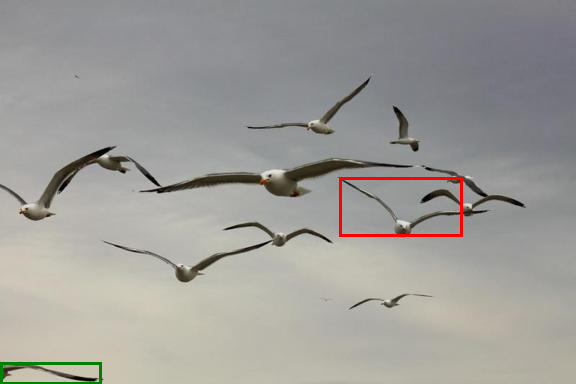

In [18]:
img1 = Image.open('/workdir/radish/hachi/OBJ_INS/phase2_V2/val/190_b1/ground_truth.jpg')
mb = [
      339,
      177,
      462,
      236
    ]
lb = [
      0,
      362,
      101,
      384
    ]

draw = ImageDraw.Draw(img1)
draw.rectangle(mb, outline='red', width=3)
draw.rectangle(lb, outline='green', width=3)
img1

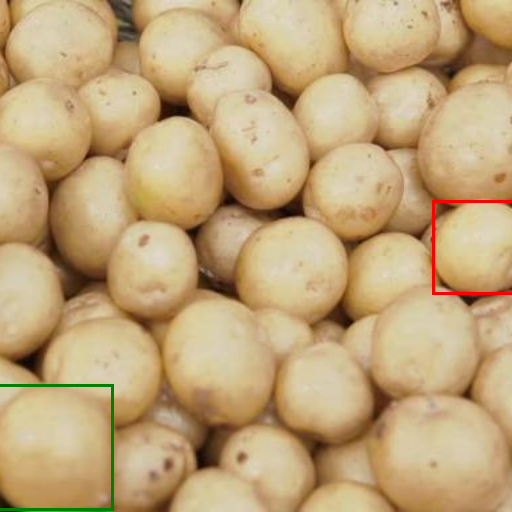

In [11]:
draw = ImageDraw.Draw(img)
draw.rectangle(mb, outline='red', width=3)
draw.rectangle(lb, outline='green', width=3)
img

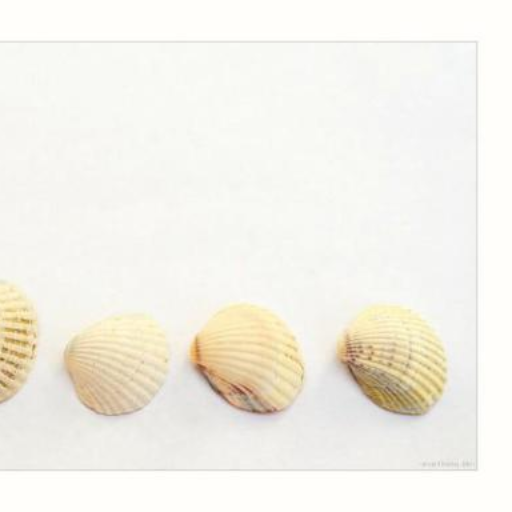

In [12]:
Image.open('/home/hachi/obj-ins/PowerPaint/validation/test/2_b1/ground_truth.png')

In [ ]:
from powerpaint.pipelines import StableDiffusionInpaintPipeline

In [ ]:

def log_validation(tokenizer, text_encoder, unet, args, accelerator, weight_dtype, step):

    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        args.pretrained_model_name_or_path,
        text_encoder=accelerator.unwrap_model(text_encoder),
        tokenizer=tokenizer,
        unet=accelerator.unwrap_model(unet),
        safety_checker=None,
        revision=args.revision,
        variant=args.variant,
        torch_dtype=weight_dtype,
        local_files_only=True, # load files from local cache
    )
    pipe = pipe.to(accelerator.device)
    pipe.set_progress_bar_config(disable=True)


    # load validation images
    image_logs = []
    for case in args.validation_data.cases:
        validation_prompts = case.prompt
        validation_image = Image.open(os.path.join(args.validation_data.data_root, case.image)).convert("RGB")
        validation_mask = Image.open(os.path.join(args.validation_data.data_root, case.mask))
        validation_mask = validation_mask.resize((validation_image.size[0], validation_image.size[1]), Image.NEAREST)
        validation_mask = validation_mask.convert("L")
        hole_value = (0, 0, 0)
        validation_image = Image.composite(
            Image.new("RGB", (validation_image.size[0], validation_image.size[1]), hole_value),
            validation_image,
            validation_mask.convert("L"),
        )
        image_grid = Image.new(
            "RGB",
            (validation_image.size[0] * (1 + len(validation_prompts)), validation_image.size[1]),
            (255, 255, 255),
        )
        image_grid.paste(validation_image, (0, 0))
        for i, p in enumerate(validation_prompts):
            with torch.autocast(accelerator.device.type):
                image = pipe(
                    promptA=p.promptA,
                    promptB=p.promptB,
                    negative_promptA=p.get("negative_promptA", None),
                    negative_promptB=p.get("negative_promptB", None),
                    tradeoff=p.tradeoff,
                    image=validation_image,
                    mask=validation_mask,
                    num_inference_steps=45,
                ).images[0]
            image_logs.append(image)
            image_grid.paste(image, (validation_image.size[0] * (i + 1), 0))
        image_grid.save(os.path.join(args.output_dir, f"{str(step).zfill(3)}_{os.path.basename(case.image)}"))
    gc.collect()
    torch.cuda.empty_cache()


    del pipe
    torch.cuda.empty_cache()

    return image_logs

In [17]:
from safetensors.torch import safe_open

with safe_open("/mnt/disk2/hachi/checkpoints/ppt-v1/text_encoder/text_encoder.safetensors", framework="pt") as f:
    P_obj = f.get_tensor(
        "text_model.embeddings.token_embedding.trainable_embeddings.P_obj"
    )

print(P_obj.shape)
print(P_obj)


torch.Size([10, 768])
tensor([[-0.0100, -0.0130, -0.0072,  ..., -0.0289,  0.0108,  0.0081],
        [ 0.0139,  0.0140, -0.0240,  ..., -0.0171,  0.0164,  0.0151],
        [ 0.0099,  0.0068, -0.0149,  ..., -0.0209,  0.0248,  0.0139],
        ...,
        [ 0.0059,  0.0043, -0.0155,  ..., -0.0191,  0.0069,  0.0076],
        [ 0.0041,  0.0046, -0.0177,  ..., -0.0138,  0.0133,  0.0110],
        [ 0.0051,  0.0017, -0.0131,  ..., -0.0182,  0.0048,  0.0140]])


In [18]:
P_obj - data['text_model.embeddings.token_embedding.trainable_embeddings.P_obj']

tensor([[-7.8510e-07, -1.4687e-06,  1.6191e-06,  ..., -1.3243e-06,
          3.0175e-07,  3.5539e-06],
        [-3.5670e-06,  1.1902e-06, -2.6301e-06,  ...,  4.1910e-07,
          3.4515e-06, -3.1292e-07],
        [-1.8990e-06,  1.2894e-06, -1.0096e-06,  ...,  3.0417e-06,
          4.8280e-06,  8.5682e-08],
        ...,
        [ 1.6964e-06, -3.9907e-07, -4.0606e-07,  ..., -4.3008e-06,
          1.8175e-06,  2.4214e-08],
        [ 4.6473e-07, -1.1944e-06,  4.5821e-06,  ..., -5.5786e-07,
         -1.2126e-06,  2.4065e-06],
        [-1.7681e-06,  3.8103e-07,  3.4394e-06,  ..., -4.2655e-07,
          3.4599e-07, -6.4261e-08]])

In [2]:
from safetensors.torch import safe_open

with safe_open("/workdir/radish/hachi/checkpoints/ppt-v1/text_encoder/text_encoder.safetensors", framework="pt") as f:
    for k in f.keys():
        tensor = f.get_tensor(k)
        print(k, tensor.shape)


text_model.embeddings.position_embedding.weight torch.Size([77, 768])
text_model.embeddings.position_ids torch.Size([1, 77])
text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_obj torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_shape torch.Size([10, 768])
text_model.embeddings.token_embedding.wrapped.weight torch.Size([49408, 768])
text_model.encoder.layers.0.layer_norm1.bias torch.Size([768])
text_model.encoder.layers.0.layer_norm1.weight torch.Size([768])
text_model.encoder.layers.0.layer_norm2.bias torch.Size([768])
text_model.encoder.layers.0.layer_norm2.weight torch.Size([768])
text_model.encoder.layers.0.mlp.fc1.bias torch.Size([3072])
text_model.encoder.layers.0.mlp.fc1.weight torch.Size([3072, 768])
text_model.encoder.layers.0.mlp.fc2.bias torch.Size([768])
text_model.encoder.layers.0.mlp.fc2.weight torch.Size([768, 3072])
text_model.encoder.layer

In [1]:
from safetensors.torch import safe_open

with safe_open("/workdir/radish/hachi/checkpoints/ppt-v1/unet/unet.safetensors", framework="pt") as f:
    for k in f.keys():
        tensor = f.get_tensor(k)
        print(k, tensor.shape)


conv_in.bias torch.Size([320])
conv_in.weight torch.Size([320, 9, 3, 3])
conv_norm_out.bias torch.Size([320])
conv_norm_out.weight torch.Size([320])
conv_out.bias torch.Size([4])
conv_out.weight torch.Size([4, 320, 3, 3])
down_blocks.0.attentions.0.norm.bias torch.Size([320])
down_blocks.0.attentions.0.norm.weight torch.Size([320])
down_blocks.0.attentions.0.proj_in.bias torch.Size([320])
down_blocks.0.attentions.0.proj_in.weight torch.Size([320, 320, 1, 1])
down_blocks.0.attentions.0.proj_out.bias torch.Size([320])
down_blocks.0.attentions.0.proj_out.weight torch.Size([320, 320, 1, 1])
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.weight torch.Size([320, 320])
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.bias torch.Size([320])
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.weight torch.Size([320, 320])
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q.weight torch.Size([320, 320])
down_blocks.0.attentions.0.transformer_blocks.0.a

ValueError: could not determine the shape of object type 'torch.storage.UntypedStorage'

In [3]:
import torch

state_dict = torch.load("/workdir/radish/hachi/New_Ouput/checkpoint-200/text_encoder/pytorch_model.bin", map_location="cpu")

for k, v in state_dict.items():
    print(k, v.shape)


text_model.embeddings.position_ids torch.Size([1, 77])
text_model.embeddings.token_embedding.weight torch.Size([49448, 768])
text_model.embeddings.position_embedding.weight torch.Size([77, 768])
text_model.encoder.layers.0.self_attn.k_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.k_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.v_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.v_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.q_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.q_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.out_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.out_proj.bias torch.Size([768])
text_model.encoder.layers.0.layer_norm1.weight torch.Size([768])
text_model.encoder.layers.0.layer_norm1.bias torch.Size([768])
text_model.encoder.layers.0.mlp.fc1.weight torch.Size([3072, 768])
text_model.encoder.layers.0.mlp.fc

In [1]:
lt = []
for i in lt:
    print(i)

In [2]:
if '1' in lt:
    print('có')

In [2]:
import torch

state_dict = torch.load("/workdir/radish/hachi/checkpoints/ppt-v2/PowerPaint_Brushnet/pytorch_model.bin", map_location="cpu")

for k, v in state_dict.items():
    print(k, v.shape)

text_model.embeddings.position_ids torch.Size([1, 77])
text_model.embeddings.token_embedding.wrapped.weight torch.Size([49408, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_shape torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_obj torch.Size([10, 768])
text_model.embeddings.position_embedding.weight torch.Size([77, 768])
text_model.encoder.layers.0.self_attn.k_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.k_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.v_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.v_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.q_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.q_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.out_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0

In [5]:
state_dict['text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt']

tensor([[ 0.0024, -0.0033, -0.0174,  ..., -0.0183,  0.0134,  0.0122],
        [ 0.0018, -0.0022, -0.0140,  ..., -0.0127,  0.0105,  0.0046],
        [-0.0006,  0.0001, -0.0137,  ..., -0.0111,  0.0125,  0.0001],
        ...,
        [-0.0042,  0.0033, -0.0111,  ..., -0.0145,  0.0117,  0.0078],
        [-0.0044,  0.0042, -0.0100,  ..., -0.0145,  0.0122,  0.0089],
        [-0.0019, -0.0012, -0.0094,  ..., -0.0143,  0.0110,  0.0110]])

In [1]:
from safetensors.torch import safe_open

with safe_open("/workdir/radish/hachi/checkpoints/ppt-v2/PowerPaint_Brushnet/diffusion_pytorch_model.safetensors", framework="pt") as f:
    for k in f.keys():
        tensor = f.get_tensor(k)
        print(k, tensor.shape)

brushnet_down_blocks.0.bias torch.Size([320])
brushnet_down_blocks.0.weight torch.Size([320, 320, 1, 1])
brushnet_down_blocks.1.bias torch.Size([320])
brushnet_down_blocks.1.weight torch.Size([320, 320, 1, 1])
brushnet_down_blocks.10.bias torch.Size([1280])
brushnet_down_blocks.10.weight torch.Size([1280, 1280, 1, 1])
brushnet_down_blocks.11.bias torch.Size([1280])
brushnet_down_blocks.11.weight torch.Size([1280, 1280, 1, 1])
brushnet_down_blocks.2.bias torch.Size([320])
brushnet_down_blocks.2.weight torch.Size([320, 320, 1, 1])
brushnet_down_blocks.3.bias torch.Size([320])
brushnet_down_blocks.3.weight torch.Size([320, 320, 1, 1])
brushnet_down_blocks.4.bias torch.Size([640])
brushnet_down_blocks.4.weight torch.Size([640, 640, 1, 1])
brushnet_down_blocks.5.bias torch.Size([640])
brushnet_down_blocks.5.weight torch.Size([640, 640, 1, 1])
brushnet_down_blocks.6.bias torch.Size([640])
brushnet_down_blocks.6.weight torch.Size([640, 640, 1, 1])
brushnet_down_blocks.7.bias torch.Size([1280]

In [1]:
from transformers import CLIPTextModel

from powerpaint.utils.utils import TokenizerWrapper, add_tokens


text_encoder=CLIPTextModel.from_pretrained(
    "/workdir/radish/hachi/checkpoints/stable-diffusion-inpainting",
    subfolder="text_encoder",
    local_files_only=True,
)
tokenizer = TokenizerWrapper(
        "/workdir/radish/hachi/checkpoints/stable-diffusion-inpainting",
        subfolder='tokenizer',
        local_files_only=True
)
add_tokens(
        tokenizer=tokenizer,
        text_encoder=text_encoder,
        placeholder_tokens=["P_ctxt", "P_shape", "P_obj"],
        initialize_tokens=["a", "a", "a"],
        num_vectors_per_token=10,
    )



/home/anaconda3/envs/powerpaint/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


12/18 08:22:51 - mmengine - INFO - Successfully add external embeddings: P_ctxt, P_shape, P_obj.
12/18 08:22:51 - mmengine - INFO - Successfully add trainable external embeddings: P_ctxt, P_shape, P_obj


In [ ]:
text_encoder.get_input_embeddings()

EmbeddingLayerWithFixes(
  (wrapped): Embedding(49408, 768)
  (trainable_embeddings): ParameterDict(
      (P_ctxt): Parameter containing: [torch.FloatTensor of size 10x768]
      (P_shape): Parameter containing: [torch.FloatTensor of size 10x768]
      (P_obj): Parameter containing: [torch.FloatTensor of size 10x768]
  )
)

In [2]:
text_encoder.get_input_embeddings().parameters()

<generator object Module.parameters at 0x7f4654ab9e40>

In [4]:
text_encoder.get_input_embeddings().trainable_embeddings.P_ctxt

Parameter containing:
tensor([[ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        ...,
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080]],
       requires_grad=True)

In [13]:
text_encoder.text_model.requires_grad_(True)
text_encoder.text_model.encoder.requires_grad_(False)
text_encoder.text_model.final_layer_norm.requires_grad_(False)
text_encoder.text_model.embeddings.position_embedding.requires_grad_(False)
# text_encoder.text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt.requires_grad_(False)
text_encoder.text_model.embeddings.token_embedding.trainable_embeddings.P_obj.requires_grad_(False)
text_encoder.text_model.embeddings.token_embedding.trainable_embeddings.P_shape.requires_grad_(False)
text_encoder.text_model.embeddings.token_embedding.wrapped.weight.requires_grad_(False)

Parameter containing:
tensor([[-0.0012,  0.0368,  0.0221,  ...,  0.0158,  0.0046, -0.0219],
        [ 0.0152,  0.0262, -0.0132,  ..., -0.0037,  0.0002,  0.0121],
        [-0.0154, -0.0131,  0.0065,  ..., -0.0206, -0.0139, -0.0025],
        ...,
        [ 0.0102, -0.0030, -0.0150,  ..., -0.0084, -0.0206,  0.0114],
        [ 0.0011,  0.0032,  0.0003,  ..., -0.0018,  0.0003,  0.0019],
        [ 0.0012,  0.0077, -0.0011,  ..., -0.0015,  0.0009,  0.0052]])

In [15]:
params = [p for p in text_encoder.parameters() if p.requires_grad]

In [16]:
params

[Parameter containing:
 tensor([[ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         ...,
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080]],
        requires_grad=True)]

In [14]:
for name, p in text_encoder.named_parameters():
    if p.requires_grad:
        print(name, p.shape)

text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt torch.Size([10, 768])


In [10]:
import torch

# Đường dẫn tới file của bạn
checkpoint_path = '/mnt/disk2/hachi/New_ouput_7/task_prompt_step_1000.pt'

# Load file
data = torch.load(checkpoint_path, map_location=torch.device('cpu'))

# Kiểm tra xem đây là State Dict hay Full Model
if isinstance(data, dict):
    print("Đây là một State Dict. Danh sách các lớp và kích thước tensor:")
    for key, value in data.items():
        print(f"{key}: {value.shape}")
else:
    print("Đây là Full Model. Kiến trúc model là:")
    print(data)

Đây là một State Dict. Danh sách các lớp và kích thước tensor:
text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_shape: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_obj: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_loc: torch.Size([10, 768])


In [11]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt']

tensor([[ 0.0024, -0.0023, -0.0102,  ..., -0.0127,  0.0168,  0.0099],
        [ 0.0022,  0.0099, -0.0118,  ..., -0.0072,  0.0153,  0.0081],
        [ 0.0073,  0.0023, -0.0149,  ..., -0.0051,  0.0157,  0.0099],
        ...,
        [-0.0066,  0.0033, -0.0138,  ..., -0.0154,  0.0180,  0.0102],
        [-0.0006,  0.0034, -0.0151,  ..., -0.0156,  0.0130,  0.0084],
        [ 0.0012, -0.0013, -0.0055,  ..., -0.0179,  0.0084,  0.0153]])

In [12]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_loc']

tensor([[ 0.0024, -0.0024, -0.0102,  ..., -0.0127,  0.0169,  0.0099],
        [ 0.0021,  0.0100, -0.0117,  ..., -0.0071,  0.0153,  0.0081],
        [ 0.0073,  0.0023, -0.0150,  ..., -0.0051,  0.0157,  0.0100],
        ...,
        [-0.0065,  0.0032, -0.0137,  ..., -0.0155,  0.0179,  0.0101],
        [-0.0005,  0.0033, -0.0151,  ..., -0.0156,  0.0129,  0.0083],
        [ 0.0012, -0.0014, -0.0055,  ..., -0.0180,  0.0083,  0.0153]])

In [13]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_loc'] - data['text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt']

tensor([[ 1.8293e-05, -6.1505e-05, -3.5468e-05,  ..., -2.0023e-06,
          7.2047e-05, -4.4504e-05],
        [-5.9925e-05,  2.5709e-05,  4.3962e-05,  ...,  4.1701e-05,
          7.4374e-05, -1.2740e-05],
        [-3.5858e-05,  2.2943e-06, -6.7805e-05,  ...,  5.5692e-05,
          6.8950e-05,  6.8674e-05],
        ...,
        [ 1.5788e-05, -7.7061e-05,  4.3971e-05,  ..., -7.2808e-05,
         -7.7883e-05, -5.6436e-05],
        [ 5.5937e-05, -7.4656e-05,  2.1468e-05,  ..., -4.9358e-05,
         -6.7722e-05, -7.0467e-05],
        [ 5.9066e-05, -7.8848e-05,  4.3277e-05,  ..., -4.0477e-05,
         -7.3305e-05, -2.1827e-05]])

In [6]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_obj']

tensor([[-0.0100, -0.0130, -0.0072,  ..., -0.0289,  0.0108,  0.0081],
        [ 0.0139,  0.0140, -0.0240,  ..., -0.0171,  0.0164,  0.0151],
        [ 0.0099,  0.0068, -0.0149,  ..., -0.0209,  0.0248,  0.0139],
        ...,
        [ 0.0059,  0.0043, -0.0155,  ..., -0.0191,  0.0069,  0.0076],
        [ 0.0041,  0.0046, -0.0177,  ..., -0.0138,  0.0133,  0.0110],
        [ 0.0051,  0.0017, -0.0131,  ..., -0.0182,  0.0048,  0.0140]])

In [19]:
import torch

# Đường dẫn tới file của bạn
checkpoint_path = '/mnt/disk2/hachi/New_ouput_7/task_prompt_step_200.pt'

# Load file
data2 = torch.load(checkpoint_path, map_location=torch.device('cpu'))

# Kiểm tra xem đây là State Dict hay Full Model
if isinstance(data2, dict):
    print("Đây là một State Dict. Danh sách các lớp và kích thước tensor:")
    for key, value in data2.items():
        print(f"{key}: {value.shape}")
else:
    print("Đây là Full Model. Kiến trúc model là:")
    print(data2)

Đây là một State Dict. Danh sách các lớp và kích thước tensor:
text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_shape: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_obj: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_loc: torch.Size([10, 768])


In [22]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_obj']- data2['text_model.embeddings.token_embedding.trainable_embeddings.P_obj']

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

# Density_map

In [1]:
print('hi')

hi


In [2]:
import os
from collections import Counter, defaultdict

from PIL import Image

train_path = "/mnt/disk2/hachi/data/train"

# Extensions you want to scan
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def iter_image_files(root):
    for img_folder in os.listdir(root):
        yield os.path.join(root, img_folder, "ground_truth.jpg")
    # for dirpath, _, filenames in os.walk(root):
    #     for fn in filenames:
    #         ext = os.path.splitext(fn)[1].lower()
    #         if ext in IMG_EXTS:
    #             yield os.path.join(dirpath, fn)

def safe_get_hw(path):
    # Fast: read header only (no full decode) for most formats
    try:
        with Image.open(path) as im:
            w, h = im.size
        if w <= 0 or h <= 0:
            return None
        return h, w
    except Exception:
        return None

def percentile(sorted_vals, p):
    # p in [0, 100]
    if not sorted_vals:
        return None
    k = (len(sorted_vals) - 1) * (p / 100.0)
    f = int(k)
    c = min(f + 1, len(sorted_vals) - 1)
    if f == c:
        return sorted_vals[f]
    return sorted_vals[f] + (sorted_vals[c] - sorted_vals[f]) * (k - f)

def ar_bucket(ar, step=0.1, min_ar=0.2, max_ar=5.0):
    # bucket AR to e.g. 0.1 increments: 1.33 -> 1.3
    ar = max(min(ar, max_ar), min_ar)
    b = round(ar / step) * step
    return f"{b:.1f}"

def main():
    size_counter = Counter()   # (H, W)
    ar_list = []
    bad_files = []

    total = 0
    for p in iter_image_files(train_path):
        total += 1
        hw = safe_get_hw(p)
        if hw is None:
            bad_files.append(p)
            continue
        h, w = hw
        size_counter[(h, w)] += 1
        ar_list.append(w / h)

    n = len(ar_list)
    print(f"Scanned files: {total}")
    print(f"Valid images : {n}")
    print(f"Unreadable   : {len(bad_files)}")

    if n == 0:
        print("No valid images found.")
        return

    ar_sorted = sorted(ar_list)
    ar_min = ar_sorted[0]
    ar_max = ar_sorted[-1]
    ar_mean = sum(ar_sorted) / n

    print("\n=== Aspect Ratio (W/H) stats ===")
    print(f"min   : {ar_min:.6f}")
    print(f"max   : {ar_max:.6f}")
    print(f"mean  : {ar_mean:.6f}")
    for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        val = percentile(ar_sorted, p)
        print(f"p{p:02d}  : {val:.6f}")

    # Common HxW
    print("\n=== Most common sizes (H x W) ===")
    for (h, w), c in size_counter.most_common(20):
        print(f"{h} x {w}  : {c}")

    # AR buckets (to see popular aspect ratios)
    bucket_counter = Counter(ar_bucket(ar, step=0.05) for ar in ar_list)
    print("\n=== Most common AR buckets (step=0.05) ===")
    for b, c in bucket_counter.most_common(20):
        print(f"AR ~ {b} : {c}")

    # Show examples for min/max AR (by size)
    # Find one file matching min/max approximately (using size map)
    print("\n=== Notes ===")
    print("AR is computed as W/H. If you want H/W instead, swap accordingly.")

if __name__ == "__main__":
    main()


Scanned files: 4653
Valid images : 4653
Unreadable   : 0

=== Aspect Ratio (W/H) stats ===
min   : 1.000000
max   : 4.994792
mean  : 1.434617
p01  : 1.000000
p05  : 1.000000
p10  : 1.062500
p25  : 1.289062
p50  : 1.445312
p75  : 1.505208
p90  : 1.778646
p95  : 1.890104
p99  : 2.716979

=== Most common sizes (H x W) ===
384 x 576  : 771
384 x 408  : 613
384 x 512  : 492
384 x 384  : 296
384 x 683  : 184
384 x 577  : 124
384 x 575  : 114
384 x 682  : 109
384 x 578  : 60
384 x 580  : 51
384 x 522  : 51
384 x 579  : 50
384 x 513  : 45
384 x 514  : 43
384 x 526  : 41
384 x 535  : 36
384 x 511  : 30
384 x 574  : 27
384 x 531  : 26
384 x 614  : 26

=== Most common AR buckets (step=0.05) ===
AR ~ 1.5 : 1395
AR ~ 1.4 : 1046
AR ~ 1.1 : 652
AR ~ 1.8 : 409
AR ~ 1.0 : 315
AR ~ 1.2 : 178
AR ~ 1.6 : 167
AR ~ 1.7 : 141
AR ~ 1.3 : 86
AR ~ 1.9 : 82
AR ~ 2.0 : 39
AR ~ 2.4 : 26
AR ~ 2.1 : 24
AR ~ 2.2 : 16
AR ~ 2.3 : 12
AR ~ 3.0 : 11
AR ~ 2.8 : 9
AR ~ 2.5 : 9
AR ~ 2.6 : 7
AR ~ 3.2 : 6

=== Notes ===
AR is 

## Check dataloader

In [1]:
print("hi")

hi


In [2]:
from powerpaint.datasets.fsc_147 import *
train_root = "/mnt/disk2/hachi/data/train"
density_root = "/mnt/disk2/hachi/data/gt_density_map_adaptive_384_VarV2"

/mnt/disk1/aiotlab/envs/powerpaint/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
items = build_index(train_root, density_root)
dataset = FSCDataset(items)

In [4]:
dataset[0]

{'pixel_values': tensor([[[ 0.7188,  0.7212,  0.7250,  ...,  0.1148,  0.1308,  0.1406],
          [ 0.6959,  0.7002,  0.7074,  ...,  0.0466,  0.0577,  0.0644],
          [ 0.6735,  0.6804,  0.6914,  ..., -0.0234, -0.0170, -0.0136],
          ...,
          [-0.9686, -0.9678, -0.9703,  ..., -0.6909, -0.6967, -0.7004],
          [-0.9676, -0.9666, -0.9698,  ..., -0.6961, -0.6883, -0.6831],
          [-0.9705, -0.9697, -0.9722,  ..., -0.6833, -0.6698, -0.6611]],
 
         [[ 0.7580,  0.7604,  0.7643,  ...,  0.1864,  0.2023,  0.2121],
          [ 0.7351,  0.7394,  0.7466,  ...,  0.1172,  0.1283,  0.1350],
          [ 0.7127,  0.7196,  0.7307,  ...,  0.0473,  0.0535,  0.0570],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -0.8253, -0.8436, -0.8542],
          [-1.0000, -1.0000, -1.0000,  ..., -0.8444, -0.8460, -0.8451],
          [-1.0000, -1.0000, -1.0000,  ..., -0.8381, -0.8333, -0.8299]],
 
         [[ 0.7266,  0.7290,  0.7329,  ...,  0.1570,  0.1700,  0.1808],
          [ 

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def show_sample(sample):
    pixel_values = sample["pixel_values"]
    mask = sample["mask"]
    density = sample["density"]

    # ===== Convert image from [-1,1] → [0,1]
    img = (pixel_values.clamp(-1, 1) + 1) / 2
    img = img.permute(1, 2, 0).cpu().numpy()

    # ===== Convert mask & density
    mask_np = mask.squeeze(0).cpu().numpy()
    density_np = density.squeeze(0).cpu().numpy()

    # ===== Overlay mask (red)
    overlay_mask = img.copy()
    overlay_mask[mask_np > 0.5] = [1, 0, 0]  # red

    # ===== Overlay density (jet heatmap)
    cmap = plt.cm.jet
    density_color = cmap(density_np)[:, :, :3]  # remove alpha

    alpha = 0.5
    overlay_density = img * (1 - alpha) + density_color * alpha

    # ===== Plot
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    axes[0, 0].imshow(img)
    axes[0, 0].set_title("Image")

    axes[0, 1].imshow(mask_np, cmap="gray")
    axes[0, 1].set_title("Mask")

    axes[0, 2].imshow(density_np, cmap="jet")
    axes[0, 2].set_title("Density")

    axes[1, 0].imshow(overlay_mask)
    axes[1, 0].set_title("Image + Mask")

    axes[1, 1].imshow(overlay_density)
    axes[1, 1].set_title("Image + Density")

    axes[1, 2].axis("off")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

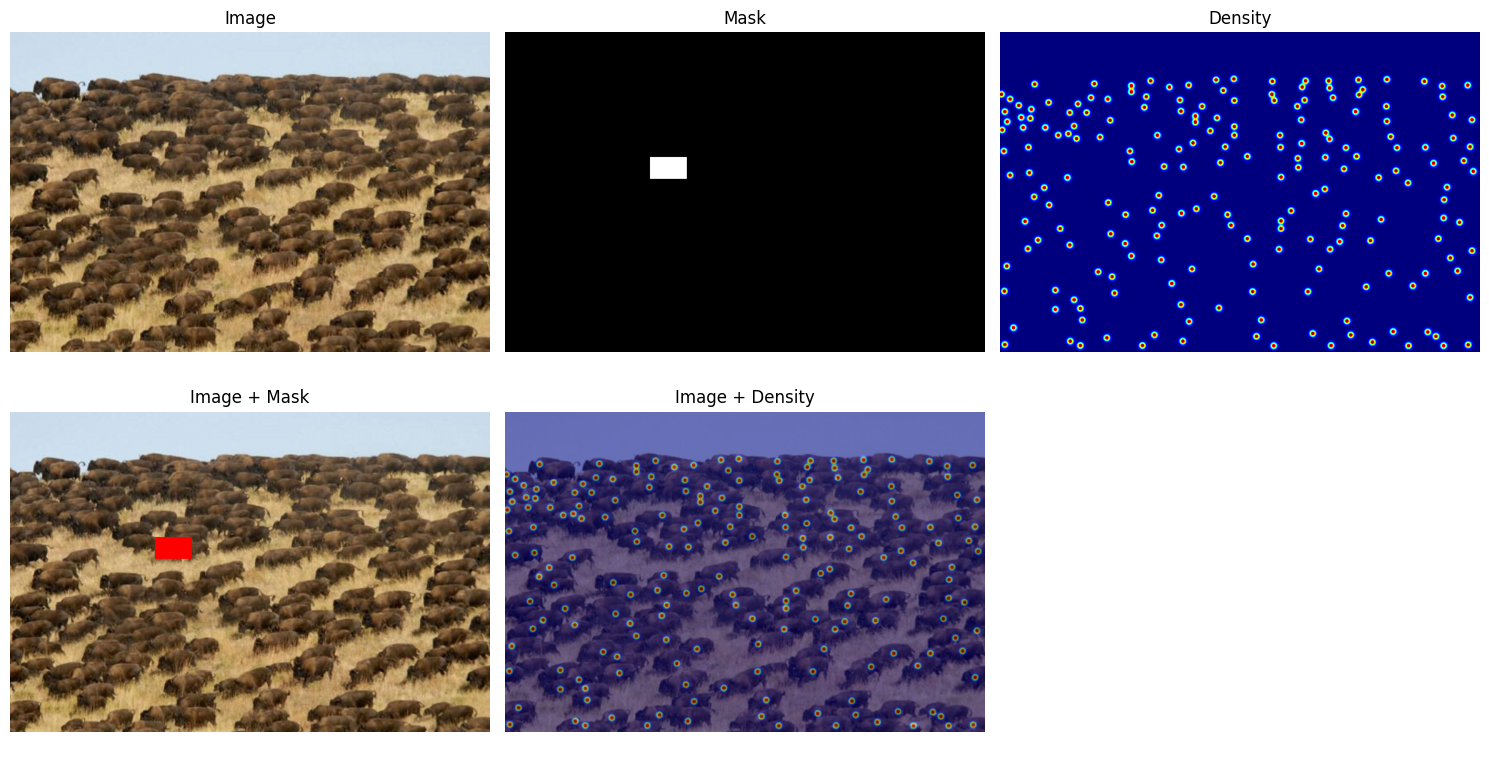

In [22]:
show_sample(dataset[4])

In [8]:
den = dataset[0]["density"]

In [12]:
den.min(), den.max()

(tensor(0.), tensor(0.2354))

In [13]:
dataset[0]['id']

'1074_b2'

In [14]:
import numpy as np
tmp = np.load(os.path.join(density_root, "1074.npy"))


In [16]:
tmp.min(), tmp.max()

(0.0, 0.005579187)

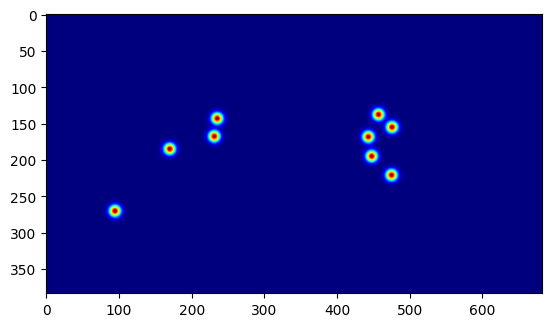

In [18]:
plt.imshow(tmp, 'jet')